In [1]:
import numpy as np

from PIL import Image

import torch

import torch.nn as nn

import torch.nn.functional as F

import torch.optim as optim

import torchvision

import torchvision.transforms as transforms


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CIFAR10 training and test datasets
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=True, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Première couche de convolution
        self.conv1 = nn.Conv2d(3, 12, 5)  # Entrée: (3, 32, 32) -> Sortie: (12, 28, 28)
        self.pool = nn.MaxPool2d(2, 2)    # Réduction: (12, 28, 28) -> (12, 14, 14)
        
        # Deuxième couche de convolution
        self.conv2 = nn.Conv2d(12, 24, 5)  # Entrée: (12, 14, 14) -> Sortie: (24, 10, 10)
                                           # Après pooling: (24, 10, 10) -> (24, 5, 5)
        
        # Couches entièrement connectées (fully connected)
        self.fc1 = nn.Linear(24 * 5 * 5, 120)  # 24*5*5 = 600
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)          # 10 sorties correspondant aux 10 classes

    def forward(self, x):
        # Passer par la première couche de convolution + ReLU + pooling
        x = self.pool(F.relu(self.conv1(x)))
        
        # Passer par la deuxième couche de convolution + ReLU + pooling
        x = self.pool(F.relu(self.conv2(x)))
        
        # Aplatir (flatten) le tenseur avant les couches entièrement connectées
        x = torch.flatten(x, 1)  # Le 1 indique qu'on ne touche pas à la première dimension (batch)
        
        # Passer par les couches entièrement connectées avec ReLU
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # Sortie finale (scores pour chaque classe)
        x = self.fc3(x)
        return x


In [5]:

# Instancier le réseau de neurones
net = NeuralNet()

# Définir la fonction de perte (Cross-Entropy Loss pour classification multiclass)
loss_function = nn.CrossEntropyLoss()

# Définir l'optimiseur (Stochastic Gradient Descent - SGD)
optimizer = optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)
#optimizer = optim.Adam(net.parameters(),lr=0.005,betas=(0.9,0.999),eps=1e-08,weight_decay=0,amsgrad=False)

# Boucle d'entraînement
for epoch in range(30):  # Entraînement sur 30 époques
    print(f'Training epoch {epoch + 1}...')

    running_loss = 0.0  # Réinitialiser la perte accumulée pour chaque époque

    for i, data in enumerate(train_loader):
        # Charger les données (inputs et labels)
        inputs, labels = data

        # Réinitialiser les gradients
        optimizer.zero_grad()

        # Passage avant
        outputs = net(inputs)

        # Calcul de la perte
        loss = loss_function(outputs, labels)

        # Rétropropagation
        loss.backward()

        # Mise à jour des poids
        optimizer.step()

        # Ajouter la perte courante à la perte accumulée
        running_loss += loss.item()

    # Afficher la perte moyenne pour cette époque
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_loader):.4f}')

Training epoch 1...
Epoch 1, Loss: 2.3023
Training epoch 2...
Epoch 2, Loss: 2.2999
Training epoch 3...
Epoch 3, Loss: 2.2962
Training epoch 4...
Epoch 4, Loss: 2.2897
Training epoch 5...
Epoch 5, Loss: 2.2751
Training epoch 6...
Epoch 6, Loss: 2.2408
Training epoch 7...
Epoch 7, Loss: 2.1619
Training epoch 8...
Epoch 8, Loss: 2.0640
Training epoch 9...
Epoch 9, Loss: 1.9848
Training epoch 10...
Epoch 10, Loss: 1.9382
Training epoch 11...
Epoch 11, Loss: 1.9037
Training epoch 12...
Epoch 12, Loss: 1.8695
Training epoch 13...
Epoch 13, Loss: 1.8325
Training epoch 14...
Epoch 14, Loss: 1.7936
Training epoch 15...
Epoch 15, Loss: 1.7524
Training epoch 16...
Epoch 16, Loss: 1.7109
Training epoch 17...
Epoch 17, Loss: 1.6729
Training epoch 18...
Epoch 18, Loss: 1.6403
Training epoch 19...
Epoch 19, Loss: 1.6124
Training epoch 20...
Epoch 20, Loss: 1.5895
Training epoch 21...
Epoch 21, Loss: 1.5673
Training epoch 22...
Epoch 22, Loss: 1.5465
Training epoch 23...
Epoch 23, Loss: 1.5255
Traini

In [6]:

# Sauvegarde des poids du modèle entraîné
torch.save(net.state_dict(), 'trained_net.pth')


In [7]:
# Recharger le modèle à partir du fichier sauvegardé
net = NeuralNet()  # Créer une nouvelle instance de la classe NeuralNet
net.load_state_dict(torch.load('trained_net.pth'))


C:\Users\HP EliteBook 850 G3\AppData\Local\Temp\ipykernel_8416\905110897.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load('trained_net.pth'

<All keys matched successfully>

In [8]:
correct = 0
total = 0

net.eval()  # Met le modèle en mode évaluation (désactive le dropout, etc.)

with torch.no_grad():  # Désactive le calcul des gradients pour économiser de la mémoire
    for data in test_loader:
        images, labels = data

        # Passage avant pour obtenir les prédictions
        outputs = net(images)

        # Obtenir la classe prédite pour chaque image
        _, predicted = torch.max(outputs, 1)

        # Mettre à jour le total d'images et le nombre de prédictions correctes
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calcul de l'accuracy
accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')


Accuracy: 49.00%


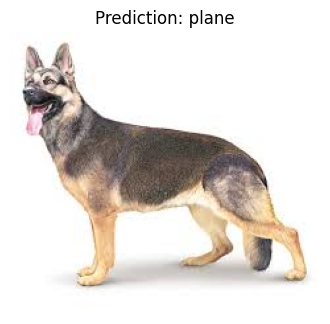

In [9]:
# Importer les bibliothèques nécessaires
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Définir la liste des noms des classes
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Définir une nouvelle transformation pour prétraiter les images
new_transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Redimensionner les images à 32x32
    transforms.ToTensor(),  # Convertir les images en tenseur PyTorch
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalisation
])

# Fonction pour charger et prétraiter une image
def load_image(image_path):
    image = Image.open(image_path)  # Charger l'image
    transformed_image = new_transform(image)  # Appliquer les transformations
    return transformed_image.unsqueeze(0), image  # Retourner le tenseur et l'image brute

# Liste des chemins des images à prédire
image_paths = [

    
     "C:\\Users\\HP EliteBook 850 G3\\Desktop\\COUR S2\\deep_learning\\datasets\\images.jpeg",
   

    
    
    
]

# Charger et prétraiter les images
data = [load_image(img) for img in image_paths]

# Mettre le modèle en mode évaluation
net.eval()

# Faire des prédictions et afficher les résultats
with torch.no_grad():  # Pas de calcul des gradients
    for i, (image_tensor, original_image) in enumerate(data):
        output = net(image_tensor)  # Obtenir les prédictions du modèle
        _, predicted = torch.max(output, 1)  # Classe prédite

        # Afficher l'image avec la prédiction
        plt.figure(figsize=(4, 4))
        plt.imshow(original_image)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[predicted.item()]}")
        plt.show()
